
<div class="alert alert-block alert-success" style="font-family:Times New Roman;color:#FFFFFF;background-color: #E7E7E7">
<h1 align="center"><span style="font-family:Times New Roman;color:#046D0B"><b>Bioestadística para Investigación Científica <br>usando Python con Inteligencia Artificial</b></span></h1>
</div>
<style>
table tr:last-child td:last-child {
  border-bottom-right-radius: 0.5rem;
}
</style>


<table align="center" style="font-size: 13px;">
<tr>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">Autor</span></th>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">:VR ROJAS</span></th>
</tr>
<tr>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">Email</span></th>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">:sacha.analytics@gmail.com</span></th>
</tr>
<tr>
    <th align="left"><span style="font-family:Monospace;font-size: 12px;">Web</span></th>
    <th align="left">:<a href="https://sacha-analytics.github.io/" style="font-family:Monospace;font-size: 13px;">sacha-analytics</a></th>
</tr>
</table>
<br>

# 1. <b>Diseño de Caso Estudio: </b>Anemia

La anemia es un transtorno en el cual el número de glóbulos rojos o eritrocitos circulantes en la sangre se ha reducido y es insuficiente para satisfacer las necesidades del organismo. En términos de salud pública, la anemia se define como una concentración de hemoglobina por debajo de dos desviaciones estándar del promedio según género, edad y altura a nivel del mar,

**Fuentes**

* <a href="https://www.datosabiertos.gob.pe/dataset/anemia">Plataforma de datos abiertos del Perú</a>.

* <a href="https://www.who.int/news-room/fact-sheets/detail/anaemia">Organización Mundial de la Salud (OMS)</a>

# **I. Marco Teórico**

## **1.1 Objetivo**
Analizar la distribución y características de casos de **Anemia** en función de las variables **Sexo, Edad** y **Tipo de Diagnóstico** utilizando métodos bioestadístico.

## **1.2 Fundamentos Bioestadísticos**

### **1.2.1 Tipos de variables**
* **Sexo**: categórica nomial (Femenino, Masculino).
* **Edad**: cuantitativa continua.
* **Tipo de Diagnóstico (Tipo de Dx)**: categórica nominal (Ej. Anemia ferropénica, megaloblástica, etc)

### **1.2.2 Métodos estadísticos relevantes**
* Estadística descriptiva univariada y bivariada
* Distribución de frecuencias.
* Medidas de tendencia central y dispersión.
* Prueba de independencia (Chi-cuadrado)
* Comparaciones de medidas (t-test, ANOVA)
* Modelos de regresión logística (para predecir DX)
* Modelos multivariantes (regresión logística si se desea modelar probabilidad de anemia)
* Validación de supuestos estadísticos

# **II. Recolección de Datos**

## **2.1. Fuentes de datos**

* <a href="https://www.datosabiertos.gob.pe">Plataforma Nacional de Datos Abiertos</a>.

* Datos para caso estudio: <a href="https://www.datosabiertos.gob.pe/dataset/anemia">Anemia</a>.

# **III. Metodología Práctica**

## **3.1. Montar Drive a Google Colaboratory**

La siguiente celda de código monta el drive en la computadora remota de Google

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


En la siguiente celda de código se define la ruta de  **Drive** en la computadora en la nube ()

In [56]:
drive_dir = "/content/drive/MyDrive/"

print(drive_dir)

/content/drive/MyDrive/


La funión `explorar_drive` permite inspeccionar cada carpeta y subcarpetas que se encuentran en el **Drive**

In [57]:
def explorar_drive(nombre_carpeta):
  import os
  ruta_drive ="/content/drive/MyDrive/"
  contenido_carpeta = os.listdir(ruta_drive + nombre_carpeta)
  n_elem = len(contenido_carpeta)

  print(f"Ruta: {ruta_drive + nombre_carpeta}")
  print(f"Numero de elementos: {n_elem}")

  for i in range(n_elem):
    print(f"({i}) {contenido_carpeta[i]}")

In [15]:
explorar_drive("Base_datos")

Ruta: /content/drive/MyDrive/Base_datos
Numero de elementos: 5
(0) fuente_de_datos.gdoc
(1) shapes
(2) biomedicina
(3) meteorologia
(4) finanzas


In [16]:
explorar_drive("Base_datos/biomedicina")

Ruta: /content/drive/MyDrive/Base_datos/biomedicina
Numero de elementos: 13
(0) datos_abiertos_vigilancia_dengue_2000_2023.csv
(1) datos_abiertos_vigilancia_malaria_2000_2008.csv
(2) datos_abiertos_vigilancia_malaria_2009_2023.csv
(3) Dataset_ExamenesLaboratorio_ConsultaExterna_PatologíasRelacionadas_Diabetes_202001_202404.csv
(4) datos_abiertos_vigilancia_zoonosis_2000_2023.csv
(5) datos_abiertos_vigilancia_iras_2000_2023.csv
(6) datos_abiertos_vigilancia_enfermedad_carrion_2000_2023.csv
(7) pmGenoma_25Septiembre2021.csv
(8) pmGenoma_27Sep2023.csv
(9) primeras_100_filas_anemia.xlsx
(10) primeras_100_filas_anemia.gsheet
(11) TB_DIGTEL_ANEMIA_TRATAMIENTOS.csv
(12) analisis_datos.docx


## **3.2. Preparar Entorno**

In [17]:
# Paquete especializado en metodos numericos
import numpy as np

# Paquete especialozado manejo de estructuras de datos tipo tablas (Data Frames)
import pandas as pd

# Paquetes especializado para generar graficas
import seaborn as sns
import matplotlib.pyplot as plt

# Paquete especializados de estadística y metodos numéricos
from scipy import stats

# Paquete especializado en estadística
import statsmodels.api as sm
import statsmodels.formula.api as smf
#from statsmodels.formula.api import ols


## **3.3. Importar Base de Datos de Anemia**

In [18]:
nombre_archivo = "TB_DIGTEL_ANEMIA_TRATAMIENTOS.csv"
data_dir = "/content/drive/MyDrive/Base_datos/biomedicina/"

df_anemia = pd.read_csv(data_dir + nombre_archivo)
print(df_anemia)

       Sexo  id_persona  Edad Tipo_edad  id_ubigeo  Fecha_atencion    Etapa  \
0         F    41031388    20         A        NaN        20230208  18a-29a   
1         F    40489600     2         A     1128.0        20230107  00a-11a   
2         M    40315865     1         A        NaN        20230207  00a-11a   
3         F    38917347    19         D     1460.0        20210511  00a-11a   
4         M    40507941     3         A     1668.0        20230224  00a-11a   
...     ...         ...   ...       ...        ...             ...      ...   
248888    M     9206744     6         A     1631.0        20230119  00a-11a   
248889    M    25824229     4         A      163.0        20210528  00a-11a   
248890    F    19472530     6         A     1161.0        20230107  00a-11a   
248891    F    33840534     4         A      242.0        20210412  00a-11a   
248892    F    19486739    84         A     1703.0        20230525     60a+   

        Diagnostico Tipo_Dx  Lab  id_eess  
0      

## **3.4. Revision de Metadatos**



In [19]:
print(df_anemia.columns.to_list())

['Sexo', 'id_persona', 'Edad', 'Tipo_edad', 'id_ubigeo', 'Fecha_atencion', 'Etapa', 'Diagnostico', 'Tipo_Dx', 'Lab', 'id_eess']


In [20]:
for i in range(len(df_anemia.columns.to_list())):
  print(f"{i}- {df_anemia.columns.to_list()[i]}")

0- Sexo
1- id_persona
2- Edad
3- Tipo_edad
4- id_ubigeo
5- Fecha_atencion
6- Etapa
7- Diagnostico
8- Tipo_Dx
9- Lab
10- id_eess


Reconocimiento de las variables en base a los archvios **Metadatos**

**Metadata de la base de datos de anemia**

**Sexo**: M:Masculino, F:Femenino

**Edad**: Edad del paciente

**Tipo_edad**: AÑO, MES, DIA, HORA

**Tipo_Dx**: Tipo de diagnostico: Definitivo, Presuntivo, Repetido

En el contexto de la anemia, los términos diagnóstico **Definitivo**, **Presuntivo** y **Repetido** se refiere a categorias utilizadas en la práctica clínica para clasificar el nivel de certeza y el proceso de diagnóstico. A continuación, se describe detalladamente cada uno de ellos, con un enfoque específico en su aplicación al diagnóstico de anemia:

 #### **3.4.1. tipo_Dx:** Definitivo (D)

 Es el diagnótico establecido con absoluta certeza, respaldado por pruebas clínicas de laboratorio o estudios complementarios que confirman de manera inequívoca la presencia y la causa específica de la anemia. Este diagnóstico se basa en evidencia objetiva y criterios de diagnósticos estandarizados.

 **Características**

*   Se alccanza tras completar una evaluación exhaustiva, que incluye análisis de sangre, estudios de médula ósea (si es necesario), prubas bioquímicas u otros métodos especializados.
* Elimina dudas sobre otras posibles causas o condiciones diferenciales.
* Especifíca el tipo de anemia (Ej. anemia **ferropénica, megaloblástica, hemolítica**) y, cuando aplica, la causa subyacente (como deficiencia de hierro, déficit de vitamina **B12** ó enfermedad crónica)



### **3.4.2. tipo_Dx:** Presuntivo (P)

Es un diagnóstico preliminar o tentativo  basado en datos clínicos, sintomáticos, antecedentes y pruebas iniciales, pero sin confirmación completa de todas las pruebas necesarias para establecer un diagnóstico definitivo. Se utiliza cuando hay una alta probabilidad de anemia, pero aún se requieren estudios adicionales para confirmar la causa exacta.

**Características**
* Se basa en hallazgos parciales, como síntomas, examen físico o pruebas básicas (Ej Hemograma)
* Puede ser suficiente para iniciar un tratamiento provisional, pero debe ser seguido por pruebas confirmatorias.
* Está sujeto a revisión  y puede cambiar una vez que se obtengan resultados más específicos.

### **3.4.3. tipo_Dx:** Repetido (R)

Se refiere a un diagnóstico que se registra nuevamente en una consulta o episodio clínico posterior, confirmando o reevaluando una condición previamente identificada (ya sea presuntiva o definitiva). Este término se usa en sistemas de codificación clínica (como CIE-10) para indicar que la anemia sigue presente o se ha reevaluado en el paciente.

**Características**
* No implica un nuevo diagnóstico, sino la confirmación o monitoreo de una condición existente.
* Puede aplicarse tanto a diagnósticos definitivos como presuntivos que se mantienen en el tiempo.
* Es común en enfermedades crónicas o recurrentes, donde el paciente requiere seguimiento continuo.

**Fuentes**

* <a href="https://www.datosabiertos.gob.pe/dataset/anemia">Plataforma de datos abiertos del Perú</a>.

* <a href="https://www.who.int/news-room/fact-sheets/detail/anaemia">Organización Mundial de la Salud (OMS)</a>

###**3.4.4. Elección de variables de interés**

In [21]:
df_interes = df_anemia[[ "Sexo","Tipo_edad","Tipo_Dx", "Edad"]]
print(df_interes)

       Sexo Tipo_edad Tipo_Dx  Edad
0         F         A       D    20
1         F         A       D     2
2         M         A       D     1
3         F         D       D    19
4         M         A       D     3
...     ...       ...     ...   ...
248888    M         A       D     6
248889    M         A       D     4
248890    F         A       D     6
248891    F         A       D     4
248892    F         A       D    84

[248893 rows x 4 columns]


In [22]:
primeras_100_filas = df_interes.head(100)
print(primeras_100_filas)

   Sexo Tipo_edad Tipo_Dx  Edad
0     F         A       D    20
1     F         A       D     2
2     M         A       D     1
3     F         D       D    19
4     M         A       D     3
..  ...       ...     ...   ...
95    M         M       D     6
96    F         A       D     2
97    F         A       D     2
98    M         A       D     2
99    M         A       D     2

[100 rows x 4 columns]


In [23]:
nombre_archivo_excel = "primeras_100_filas_anemia.xlsx"
ruta_completa_excel = data_dir + nombre_archivo_excel

primeras_100_filas.to_excel(ruta_completa_excel, index=False)

In [24]:
edad = df_interes["Edad"]
print(edad)

0         20
1          2
2          1
3         19
4          3
          ..
248888     6
248889     4
248890     6
248891     4
248892    84
Name: Edad, Length: 248893, dtype: int64


## **3.5. Análisis Estadístico Descriptivo Univariado y Bivariado**


Esta sección se enfoca en realizar análisis estadístico descriptivo sobre las variables seleccionadas del DataFrame `df_interes`: Sexo, Edad y Tipo_Dx. Cubriremos estadísticas descriptivas univariadas (análisis de variable individual) y bivariadas (análisis de la relación entre dos variables).

### **3.5.1. Distribución de frecuencia de datos categóricos por columna (análisis univariado)**

Para variables categóricas como **Sexo, Tipo_edad** y **Tipo_Dx**, el análisis descriptivo más común es observar la distribución de frecuencias. Esto nos indica cuántas veces aparece cada valor único en la columna.

In [25]:
print(df_interes["Sexo"].value_counts())

print(df_interes["Tipo_edad"].value_counts())

print(df_interes["Tipo_Dx"].value_counts())


Sexo
M    126255
F    122638
Name: count, dtype: int64
Tipo_edad
A    137592
M    111104
D       197
Name: count, dtype: int64
Tipo_Dx
D    248398
R       454
P        41
Name: count, dtype: int64


### **3.5.2. Relación de datos categóricos vs numéricos (análisis bivariado)**

Para explorar la relación entre una variable categórica (**Sexo**) y una variable numérica (**Edad**), un gráfico de cajas (boxplot) es una visualización adecuada.

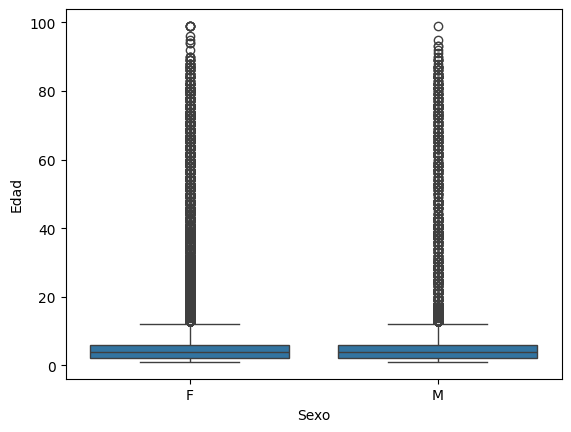

In [26]:
sns.boxplot(x="Sexo", y="Edad", data=df_interes)
plt.show()


### **3.5.3. Distribución de la variable "Edad"**

In [27]:
# Estadísticas descriptivas para la variable 'Edad'
print("Estadísticas Descriptivas para 'Edad':")
print(df_interes["Edad"].describe())
print("\n" + "="*50 + "\n") # Separador para mayor claridad

Estadísticas Descriptivas para 'Edad':
count    248893.000000
mean          4.765341
std           5.621249
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          99.000000
Name: Edad, dtype: float64




Visualización de la Distribución para 'Edad' (Histograma):


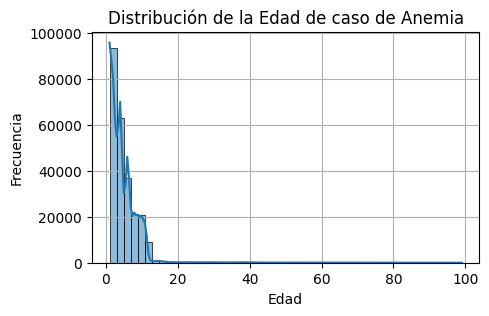

In [28]:
# Histograma para visualizar la distribución de 'Edad'
print("Visualización de la Distribución para 'Edad' (Histograma):")
plt.figure(figsize=(5, 3)) # (ncols, nfil) Establece el tamaño de la figura para el gráfico

sns.histplot(df_interes["Edad"], bins=50, kde=True) # Crea el histograma

plt.title("Distribución de la Edad de caso de Anemia") # Añade un título al gráfico
plt.xlabel("Edad") # Añade una etiqueta al eje x
plt.ylabel("Frecuencia") # Añade una etiqueta al eje y
plt.grid(True) # Añade una cuadrícula al gráfico
plt.show() # Muestra el gráfico

### **3.5.4. Análisis de Medidas de Tendencia Central y Dispersión**

Vamos a calcular medidas de tendencia central (como la media, mediana y moda) y medidas de dispersión (como la desviación estándar, varianza y rango) para las variables **Sexo, Edad** y **Tipo_Dx**.

In [29]:
# Análisis para la variable 'Edad' (Cuantitativa)
print("Análisis para la variable 'Edad':")

# Medidas de Tendencia Central para 'Edad'
print(f"  Media: {df_interes['Edad'].mean():.2f}")
print(f"  Mediana: {df_interes['Edad'].median():.2f}")
print(f"  Moda: {df_interes['Edad'].mode()[0]}") # mode() puede devolver múltiples valores si hay un empate
print("\n")

# Medidas de Dispersión para 'Edad'
print(f"  Desviación Estándar: {df_interes['Edad'].std():.2f}")
print(f"  Varianza: {df_interes['Edad'].var():.2f}")
print(f"  Rango: {df_interes['Edad'].max() - df_interes['Edad'].min()}")
print(f"  Cuartil 1 (Q1): {df_interes['Edad'].quantile(0.25):.2f}")
print(f"  Cuartil 3 (Q3): {df_interes['Edad'].quantile(0.75):.2f}")
print(f"  Rango Intercuartílico (IQR): {df_interes['Edad'].quantile(0.75) - df_interes['Edad'].quantile(0.25):.2f}")
print("\n" + "="*50 + "\n") # Separador

# Análisis para la variable 'Sexo' (Categórica)
print("Análisis para la variable 'Sexo':")

# Medida de Tendencia Central para 'Sexo' (Moda)
print(f"  Moda: {df_interes['Sexo'].mode()[0]}") # La categoría más frecuente
print("\n" + "="*50 + "\n") # Separador

# Análisis para la variable 'Tipo_edad' (Categórica)
print("Análisis para la variable 'Tipo_edad':")

# Medida de Tendencia Central para 'Tipo_edad' (Moda)
print(f"  Moda: {df_interes['Tipo_edad'].mode()[0]}") # La categoría más frecuente
print("\n" + "="*50 + "\n") # Separador

# Análisis para la variable 'Tipo_Dx' (Categórica)
print("Análisis para la variable 'Tipo_Dx':")

# Medida de Tendencia Central para 'Tipo_Dx' (Moda)
print(f"  Moda: {df_interes['Tipo_Dx'].mode()[0]}") # La categoría más frecuente
print("\n" + "="*50 + "\n") # Separador

Análisis para la variable 'Edad':
  Media: 4.77
  Mediana: 4.00
  Moda: 1


  Desviación Estándar: 5.62
  Varianza: 31.60
  Rango: 98
  Cuartil 1 (Q1): 2.00
  Cuartil 3 (Q3): 6.00
  Rango Intercuartílico (IQR): 4.00


Análisis para la variable 'Sexo':
  Moda: M


Análisis para la variable 'Tipo_edad':
  Moda: A


Análisis para la variable 'Tipo_Dx':
  Moda: D




## **3.6. Estadística inferencial:** pruebas de hipótesis

### **3.6.1. Chi-cuadrado**
La prueba de hipótesis no paramétrica **Chi-cuadrado** es una técnica estadística fundamental para analizar datos categóricos, es decir, datos que se pueden agrupar en categorías (com sexo, tipo de enfermedad, opinión, etc.). Se considera **no paramétrica** porque no asume que los datos sigan una distribución de probabilidad específica (como la distribución normal), lo que la hace muy útil en situaciones donde las suposiciones de pruebas paramétricas no se cumplen.

<b>¿Por qué se usa la prueba de Chi-cuadrado?</b>
<ul>
  <li>Se aplica a <b>datos categóricos</b> en forma de tablas de frecuencias.</li>
  <li> Se utiliza para determinar si existe una relación o asociación significativa entre dos variables (<b>prueba de independencia</b>).</li>
  <li> Se usa para comparar una distribución observada con una distribución teórica (<b>prueba de bondad de ajuste</b>).</li>
  <li> Sirve para conocer si la distribución de una variable categórica es la misma en dos o más poblaciones diferentes (<b>prueba de homogeneidad</b>).</li>
</ul>



**Hipótesis**
* **Hipótesis Nula ($H_{0}$)**: No hay una relación ó asociación entre dos variables categóricas (las variables son independientes).

* **Hipóteisis Alternativa ($H_{1}$)**: Hay una relación ó asociación significativa entre dos variables categóricas.
$ $

**Interpretación**
* Si el valor p (p-value) es **mayor** que el nivel de significancia ($α = 0.05$): No se rechaza **Hipótesis Nula ($H_{0}$)**. Por tanto, no hay evidencia de relación ó asociación entre variables.

* Si el valor p es **menor** que el nivel de significancia: Se rechaza la **Hipóteisis Nula ($H_{0}$)**. Por tanto, Existe evidencia estadística de relación o asociación entre las variables.
$ $

**Consideraciones claves**

* **Tamaño muestral**: Requiere frecuencias esperadas $\geq 5$ en cada celda.
* **Variables categóricas**: No aplica para variables continuas.
* **Direccionalidad**: Chi-Cuadrado solo detecta relación o asociación , **no causalida**.

**Nota**:

Diversos ejemplo aplicativos para generar tabla de contingenci

In [30]:
dx_D = df_interes[df_interes["Tipo_Dx"]=="D"]
print(dx_D)

print("="*40)

print(dx_D["Tipo_Dx"].value_counts())

print("="*40)

print(df_interes["Tipo_Dx"].value_counts())

       Sexo Tipo_edad Tipo_Dx  Edad
0         F         A       D    20
1         F         A       D     2
2         M         A       D     1
3         F         D       D    19
4         M         A       D     3
...     ...       ...     ...   ...
248888    M         A       D     6
248889    M         A       D     4
248890    F         A       D     6
248891    F         A       D     4
248892    F         A       D    84

[248398 rows x 4 columns]
Tipo_Dx
D    248398
Name: count, dtype: int64
Tipo_Dx
D    248398
R       454
P        41
Name: count, dtype: int64


In [31]:
tabla_sx_D = pd.crosstab(dx_D["Sexo"], dx_D["Tipo_Dx"])
print(tabla_sx_D)

Tipo_Dx       D
Sexo           
F        122359
M        126039


aplicación tabla de contingencia original del caso estudio

In [32]:
tabla = pd.crosstab(df_interes["Sexo"], df_interes["Tipo_Dx"])
print(tabla)

Tipo_Dx       D   P    R
Sexo                    
F        122359  26  253
M        126039  15  201


In [33]:
"""
Aplicar la prueba de Chi-cuadrado de independencia
---------------------------------------------------
  chi2_stat : Esta variable almacena el estadístico Chi-cuadrado

  p_valor         : Esta variable almacena el valor p, que representa la
                    la probabilidad de observar los datos si no ubiera
                    relación entre las variables

  dof             : En esta variable contine los grados de libertar, que
                    es un parámetro relacionado con el tamaño de la muestra
                    y el número de categorias en las variables.

  freq_esperadas  : A esta variable se le asigna las frecuencias esperadas
                    para cada celda de la tabla de contingencia si no hubiera
                    relación entre las variables.
"""

chi2_stat, p_valor, dof, freq_esperadas = stats.chi2_contingency(tabla_sx_D)

In [34]:
print("Prueba de Chi-cuadrado de Independencia:")
print(f"Estadístico Chi-cuadrado: {chi2_stat:.3f}")
print(f"Grados de libertad: {dof}")
print(f"p-valor: {p_valor:.3f}\n")

alpha = 0.05 # Nivel de significancia
# Interpretación:
print("\nResultado:")
if p_valor >= alpha:
  print("\tNo se rechaza H0:\n")
  print("\tNo hay una relación ó asociación significativa entre Sexo y Tipo_Dx.\n")
else:
  print("\tSe rechaza H0:\n")
  print("\tHay una relación ó asociación significativa entre Sexo y Tipo_Dx.\n")

Prueba de Chi-cuadrado de Independencia:
Estadístico Chi-cuadrado: 0.000
Grados de libertad: 0
p-valor: 1.000


Resultado:
	No se rechaza H0:

	No hay una relación ó asociación significativa entre Sexo y Tipo_Dx.



Prueba de Chi-cuadrado de Independencia:

Estadístico Chi-cuadrado: 10.865

Grados de libertad: 2

p-valor: 0.004


Resultado:

	Se rechaza H0:

	Hay una relación ó asociación significativa entre Sexo y Tipo_Dx.

### **3.6.2. Comparación de medidas:** prueba de hipótesis T-test

La prueba **T-test** (también conocido como **t de Student**) se utiliza para comparar las medias de dos muestras independientes. En este caso, las dos muestras son las edades de los individuos masculinos y femeninos.

**El T-test** es una herramienta fundamental en bioestadística que permite tomar decisiones basadas en evidencia sobre diferencias entre grupos, siendo especialmente valioso en investigación médica y epidemiológica donde las decisiones pueden tener implicaciones importantes para la salud pública.



**Supuestos del T-test**
* Los datos deben seguir una distribución aproximadamente normal (verificar con histogramas o pruebas como **Shapiro-Wilk**).

**Hipótesis**
* **Hipótesis Nula ($H_{0}$)**: No hay una diferencia significativa en la media de la edad entre hombres y mujeres (medias iguales).

* **Hipóteisis Alternativa ($H_{1}$)**: Hay una diferencia significativa en la media de la edad entre hombres y mujeres (medias diferentes).

**Interpretación**

* si **p-valor $\lt \alpha$**, se **rechaza la hipótesis nula ($H_{0}$)**: hay evidencia estadísticamente significativa de una diferencia entre los grupos. Generalmente,  $\alpha = 0.05$, donde $\alpha$ es el nivel de significancia.
* si p-valor $\geq \alpha$, **No** se **rechaza la hipótesis nula** ($H_{0}$): no hay evidencia suficiente para afirmar que las medias son distintas

In [35]:
# Separar la variable 'Edad' en dos grupos basados en la variable 'Sexo'
edad_femenino = df_interes[df_interes["Sexo"] == "F"]["Edad"]
edad_masculino = df_interes[df_interes["Sexo"] == "M"]["Edad"]

print(edad_femenino)
print(edad_masculino)

0         20
1          2
3         19
5          1
7          2
          ..
248885     4
248886     6
248890     6
248891     4
248892    84
Name: Edad, Length: 122638, dtype: int64
2         1
4         3
6         1
8         8
9         1
         ..
248880    3
248881    6
248887    4
248888    6
248889    4
Name: Edad, Length: 126255, dtype: int64


**Nota**:

Ejemplo adicional aplicativo

In [36]:
df_f = df_interes[df_interes["Sexo"]=="F"]["Edad"]
print(df_f)

0         20
1          2
3         19
5          1
7          2
          ..
248885     4
248886     6
248890     6
248891     4
248892    84
Name: Edad, Length: 122638, dtype: int64


**Nota**:

Ejemplo adicional aplicativo

In [37]:
dd_years = df_interes[df_interes["Tipo_edad"]=="A"]
print(dd_years)

print(dd_years["Tipo_edad"].value_counts())

       Sexo Tipo_edad Tipo_Dx  Edad
0         F         A       D    20
1         F         A       D     2
2         M         A       D     1
4         M         A       D     3
5         F         A       D     1
...     ...       ...     ...   ...
248888    M         A       D     6
248889    M         A       D     4
248890    F         A       D     6
248891    F         A       D     4
248892    F         A       D    84

[137592 rows x 4 columns]
Tipo_edad
A    137592
Name: count, dtype: int64


**Nota**:

Ejemplo adicional aplicativo

In [38]:
dd_adulto_mayor = dd_years[(dd_years["Edad"]>=60) & (dd_years["Edad"]<100)]
print(dd_adulto_mayor)
print(dd_adulto_mayor["Tipo_edad"].value_counts())

       Sexo Tipo_edad Tipo_Dx  Edad
311       M         A       D    75
312       M         A       D    84
424       F         A       D    70
425       M         A       D    69
491       F         A       D    81
...     ...       ...     ...   ...
231679    F         A       D    78
237405    F         A       D    82
247719    F         A       D    71
247722    F         A       D    87
248892    F         A       D    84

[630 rows x 4 columns]
Tipo_edad
A    630
Name: count, dtype: int64


**Nota**:

Ejemplo adicional aplicativo

In [39]:
dd_adolecentes = dd_years[(dd_years["Edad"]>=60) & (dd_years["Edad"]<100)]
print(dd_adulto_mayor)
print(dd_adulto_mayor["Tipo_edad"].value_counts())

       Sexo Tipo_edad Tipo_Dx  Edad
311       M         A       D    75
312       M         A       D    84
424       F         A       D    70
425       M         A       D    69
491       F         A       D    81
...     ...       ...     ...   ...
231679    F         A       D    78
237405    F         A       D    82
247719    F         A       D    71
247722    F         A       D    87
248892    F         A       D    84

[630 rows x 4 columns]
Tipo_edad
A    630
Name: count, dtype: int64


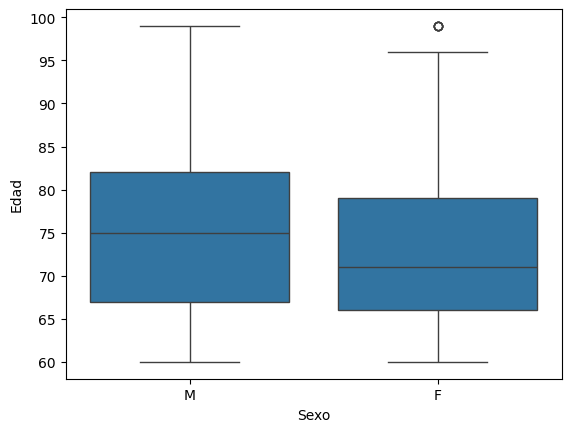

In [40]:
sns.boxplot(x="Sexo", y="Edad", data=dd_adulto_mayor)
plt.show()

Continuación de la prueba de **T-test**

In [41]:
# Realizar la prueba T-test independiente
# equal_var=True asume varianzas iguales (T-test estándar).
# Si no estamos seguros de la igualdad de varianzas, podemos usar equal_var=False (Welch's T-test).
t_stat, p_valor_ttest = stats.ttest_ind(edad_femenino, edad_masculino, equal_var=True)

print("Prueba T-test Independiente para la Edad entre Sexo Femenino y Masculino:")
print(f"Estadístico T: {t_stat:.3f}")
print(f"p-valor: {p_valor_ttest:.13f}\n")

# Interpretación del p-valor
alpha = 0.05 # Nivel de significancia comúnmente utilizado

print("Interpretación del resultado:")
if p_valor_ttest > alpha:
  print("\tno se rechaza H0.")
  print("\tConcluimos que no existe una diferencia estadísticamente significativa en la media de la edad entre el sexo femenino y masculino.")

else:
  print("\tSe rechaza H0.")
  print("\tConcluimos que existe una diferencia estadísticamente significativa en la media de la edad entre el sexo femenino y masculino.")


# Opcional: Mostrar las medias de edad para cada grupo
print("\nMedias de Edad por Sexo:")
print(f"\tMedia de Edad (Femenino): {edad_femenino.mean():.2f}")
print(f"\tMedia de Edad (Masculino): {edad_masculino.mean():.2f}")

Prueba T-test Independiente para la Edad entre Sexo Femenino y Masculino:
Estadístico T: 26.119
p-valor: 0.0000000000000

Interpretación del resultado:
	Se rechaza H0.
	Concluimos que existe una diferencia estadísticamente significativa en la media de la edad entre el sexo femenino y masculino.

Medias de Edad por Sexo:
	Media de Edad (Femenino): 5.06
	Media de Edad (Masculino): 4.48


### **3.6.3. Prueba de hipótesis paramétrica Shapiro-Wilk**

La **prueba de Shapiro-Wilk** es un método estadístico utilizado para evaluar si una muestra de datos proviene de una distribución normal. Es una de las pruebas más comunes y poderosas para verificar la normalidad de los datos, lo cual es un supuesto clave en muchas pruebas estadísticas paramétricas, como la t de Student o ANOVA. En investigación, esta prueba es útil para determinar si los datos cumplen con los requisitos de normalidad antes de aplicar métodos estadísticos que asumen una distribución normal.

**Hipótesis para la prueba Shapiro-Wilk**
* **Hipótesis Nula ($H_{0}$)**: Los datos siguen una distribución normal.

* **Hipóteisis Alternativa ($H_{1}$)**: Los datos **No** siguen una distribución normal.

**Interpretación**

* si **p-valor $\leq \alpha$**, se **rechaza la hipótesis nula ($H_{0}$)**: Los datos **no siguen una distribución normal**. Generalmente,  $\alpha = 0.05$, donde $\alpha$ es el nivel de significancia.

* si **p-valor $\gt \alpha$**, no se **rechaza la hipótesis nula** ($H_{0}$): Los datos no difieren de una distribución normal (se asume normalidad).

In [42]:
# Realizar la prueba de Shapiro-Wilk para el grupo Femenino
shapiro_femenino_stat, shapiro_femenino_p = stats.shapiro(edad_femenino)

print("Prueba de Shapiro-Wilk para la Edad (Sexo Femenino):")
print(f"Estadístico Shapiro-Wilk: {shapiro_femenino_stat:.3f}")
print(f"p-valor: {shapiro_femenino_p:.3f}\n")

# Interpretación para el grupo Femenino
alfa_shapiro = 0.05
print("Interpretación para el grupo Femenino:")
if shapiro_femenino_p > alfa_shapiro:
  print(f"\tDado que el p-valor ({shapiro_femenino_p:.3f}) es mayor o igual que el nivel de significancia ({alfa_shapiro}),")
  print("\tno se rechaza H0.")
  print("\tConcluimos que la distribución de la Edad en el grupo Femenino se ajusta a una distribución normal.")

else:
  print(f"\tDado que el p-valor ({shapiro_femenino_p:.3f}) es menor que el nivel de significancia ({alfa_shapiro}),")
  print("\tse rechaza H0.")
  print("\tConcluimos que la distribución de la Edad en el grupo Femenino no es significativamente normal.")


print("\n" + "="*50 + "\n") # Separador

# Realizar la prueba de Shapiro-Wilk para el grupo Masculino
shapiro_masculino_stat, shapiro_masculino_p = stats.shapiro(edad_masculino)

print("Prueba de Shapiro-Wilk para la Edad (Sexo Masculino):")
print(f"Estadístico Shapiro-Wilk: {shapiro_masculino_stat:.3f}")
print(f"p-valor: {shapiro_masculino_p:.3f}\n")

# Interpretación para el grupo Masculino
print("Interpretación para el grupo Masculino:")
if shapiro_masculino_p > alfa_shapiro:
  print(f"\tDado que el p-valor ({shapiro_masculino_p:.3f}) es mayor o igual que el nivel de significancia ({alfa_shapiro}),")
  print("\tno se rechaza H0.")
  print("\tConcluimos que la distribución de la Edad en el grupo Masculino se ajusta a una distribución normal.")

else:
  print(f"\tDado que el p-valor ({shapiro_masculino_p:.3f}) es menor que el nivel de significancia ({alfa_shapiro}),")
  print("\tse rechaza H0.")
  print("\tConcluimos que la distribución de la Edad en el grupo Masculino no es significativamente normal.")

print("\n" + "="*50 + "\n") # Separador

# Ahora procedemos con el T-test, considerando los resultados de la prueba de normalidad.
# Si las distribuciones no son normales, podrías considerar usar una prueba no paramétrica
# equivalente al T-test, como la prueba U de Mann-Whitney.

Prueba de Shapiro-Wilk para la Edad (Sexo Femenino):
Estadístico Shapiro-Wilk: 0.504
p-valor: 0.000

Interpretación para el grupo Femenino:
	Dado que el p-valor (0.000) es menor que el nivel de significancia (0.05),
	se rechaza H0.
	Concluimos que la distribución de la Edad en el grupo Femenino no es significativamente normal.


Prueba de Shapiro-Wilk para la Edad (Sexo Masculino):
Estadístico Shapiro-Wilk: 0.557
p-valor: 0.000

Interpretación para el grupo Masculino:
	Dado que el p-valor (0.000) es menor que el nivel de significancia (0.05),
	se rechaza H0.
	Concluimos que la distribución de la Edad en el grupo Masculino no es significativamente normal.




/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 122638.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 126255.
  res = hypotest_fun_out(*samples, **kwds)


### **3.6.4. Comparación de medidas:** Anova

  La prueba de hipótesis ANOVA (Análisis de la Varianza) es una herramienta estadística paramétrica que se utiliza para comparar las medias de tres o más grupos independientes y determinar si existen diferencias significativas entre ellas. Aunque la ANOVA es relativamente robusta a la falta de la normalidad con tamaños de muestra grandes, la homogeneidad de varianzas es más crítica.




**Nota Importante para ANOVA**

 * **Normalidad**: Las distribuciones de los residuos (o de la variable dependiente dentro de cada grupo) son aproximadamente normales.

 * **Homogeneidad de Varianzas**: Las varianzas de la variable dependiente son aproximadamente iguales en todos los grupos.

 * **Independencia**: Las observaciones son independientes.


Evaluaremos la normalidad de la variable **Edad** para cada una de las categorias de **Tipo_Dx** empleando la prueba de Shapiro-Wilk

 **Hipótesis para prueba de normalidad:** Shapiro-Wilk
* **Hipótesis Nula ($H_{0}$)**: La muestra proviene de una distribución normal.

* **Hipóteisis Alternativa ($H_{1}$)**: La muestra no proviene de una distribución normal.

In [43]:
# Separar la variable 'Edad' en grupos basados en la variable 'Tipo_Dx'
grupos_tipo_dx = df_interes.groupby("Tipo_Dx")
print(grupos_tipo_dx)

In [44]:
nombre_grupos = grupos_tipo_dx.groups.keys()
print(nombre_grupos)

dict_keys(['D', 'P', 'R'])


In [45]:
Dx_D = grupos_tipo_dx.get_group("D")
print(Dx_D)
print(Dx_D["Tipo_Dx"].value_counts())
print(df_interes["Tipo_Dx"].value_counts())
#print(Dx_D["Edad"].describe())

       Sexo Tipo_edad Tipo_Dx  Edad
0         F         A       D    20
1         F         A       D     2
2         M         A       D     1
3         F         D       D    19
4         M         A       D     3
...     ...       ...     ...   ...
248888    M         A       D     6
248889    M         A       D     4
248890    F         A       D     6
248891    F         A       D     4
248892    F         A       D    84

[248398 rows x 4 columns]
Tipo_Dx
D    248398
Name: count, dtype: int64
Tipo_Dx
D    248398
R       454
P        41
Name: count, dtype: int64


Implementar una función para realizar pruebas de hipótesis (distribución normal) Shapiro-Wilk.

In [46]:
def pruebaH_shapiroWilk(df, variable, alpha=None):
  shapiro_stat, shapiro_p = stats.shapiro(df[variable])

  print(f"Prueba de Shapiro-Wilk para {variable}:")
  print(f"\tEstadístico Shapiro-Wilk: {shapiro_stat:.3f}")
  print(f"\tp-valor: {shapiro_p:.3f}")

  # Interpretación
  if shapiro_p < alpha:
    print(f"\tSe rechaza H0. La distribución de la Edad en este grupo NO es significativamente normal.")
  else:
    print(f"\tNo se rechaza H0. La distribución de la Edad en este grupo PUEDE ser normal.")

Implementar una función para realizar pruebas de hipótesis (distribución normal) Jerque-Bera.

In [47]:
def pruebaH_jerqueBera(df, variable, alpha):
  jb_test= sm.stats.jarque_bera(df[variable])

  # Interpretación
  print(f"Prueba de Jarque-Bera para {variable}:")
  print(f"\tEstadístico = {jb_test[0]:.4f}, p-valor = {jb_test[1]:.4f}")

  if jb_test[1] < alpha:
    print("\tSe rechaza la hipótesis nula: Los datos NO siguen una distribución normal.\n")

  else:
    print("\tNo se rechaza la hipótesis nula: Los datos siguen una distribución normal.\n")

In [48]:
print(Dx_D)

       Sexo Tipo_edad Tipo_Dx  Edad
0         F         A       D    20
1         F         A       D     2
2         M         A       D     1
3         F         D       D    19
4         M         A       D     3
...     ...       ...     ...   ...
248888    M         A       D     6
248889    M         A       D     4
248890    F         A       D     6
248891    F         A       D     4
248892    F         A       D    84

[248398 rows x 4 columns]


In [49]:
pruebaH_shapiroWilk(Dx_D, "Edad", 0.05)

Prueba de Shapiro-Wilk para Edad:
	Estadístico Shapiro-Wilk: 0.518
	p-valor: 0.000
	Se rechaza H0. La distribución de la Edad en este grupo NO es significativamente normal.


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 248398.
  res = hypotest_fun_out(*samples, **kwds)


In [50]:
pruebaH_jerqueBera(Dx_D, "Edad", 0.05)

Prueba de Jarque-Bera para Edad:
	Estadístico = 58285036.4549, p-valor = 0.0000
	Se rechaza la hipótesis nula: Los datos NO siguen una distribución normal.



En tu DataFrame **df_interes**, la variable numérica es **Edad**, y la variable categórica con múltiples categorías que podemos usar para agrupar es **Tipo_Dx** (Definitivo, Presuntivo, Repetido) o potencialmente la combinación de **Sexo** y **Tipo_Dx**.

Acontinuación, realizaremos una prueba ANOVA para comparar la media de la variable **Edad** entre los grupos definidos por **Tipo_Dx**.

 **Hipótesis para la prueba ANOVA**
* **Hipótesis Nula ($H_{0}$)**: Las medias de todos los grupos son iguales.
* **Hipótesis Alternativa ($H_{1}$)**: Hay al menos un par de grupos cuyas medias de edad son significativamente diferentes.

In [51]:
# Preparar los datos: asegurar que 'Tipo_Dx' es de tipo category si no lo es,
# ols puede manejar strings, es buena práctica.
df_interes['Tipo_Dx'] = df_interes['Tipo_Dx'].astype('category')
print(df_interes)

       Sexo Tipo_edad Tipo_Dx  Edad
0         F         A       D    20
1         F         A       D     2
2         M         A       D     1
3         F         D       D    19
4         M         A       D     3
...     ...       ...     ...   ...
248888    M         A       D     6
248889    M         A       D     4
248890    F         A       D     6
248891    F         A       D     4
248892    F         A       D    84

[248893 rows x 4 columns]


/tmp/ipykernel_9255/4012265541.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_interes['Tipo_Dx'] = df_interes['Tipo_Dx'].astype('category')


In [52]:
# Realizar la prueba ANOVA usando statsmodels
# La fórmula 'Edad ~ C(Tipo_Dx)' indica que 'Edad' es la variable dependiente
# y 'Tipo_Dx' es la variable independiente categórica (C() asegura que se trate como categórica)
modelo_anova = smf.ols('Edad ~ C(Tipo_Dx)', data = df_interes).fit() # Ajusta el modelo a los datos
tabla_anova = sm.stats.anova_lm(modelo_anova, typ=2) # typ=2 para el tipo de suma de cuadrados

print("Resultado de la Prueba ANOVA (Comparación de Edad entre Tipos de Diagnóstico):")
print(tabla_anova)

# Interpretación del p-valor de la ANOVA
p_valor_anova = tabla_anova['PR(>F)']['C(Tipo_Dx)']
alfa_anova = 0.05

print("\nInterpretación del resultado de la ANOVA:")
if p_valor_anova < alfa_anova:
    print(f"\tDado que el p-valor de la ANOVA ({p_valor_anova:.3f}) es menor que el nivel de significancia ({alfa_anova}),")
    print("\tse rechaza la hipótesis nula.")
    print("\tConcluimos que existe una diferencia estadísticamente significativa\n\t en la media de la edad entre al menos dos de los tipos de diagnóstico (Definitivo, Presuntivo, Repetido).")
else:
    print(f"\tDado que el p-valor de la ANOVA ({p_valor_anova:.3f}) es mayor o igual que el nivel de significancia ({alfa_anova}),")
    print("\tno se rechaza la hipótesis nula.")
    print("\tConcluimos que no existe una diferencia estadísticamente significativa general en la media de la edad entre los diferentes tipos de diagnóstico.")

# Opcional: Mostrar las medias de Edad por grupo para ver las diferencias (si ANOVA fue significativa)
print("\nMedias de Edad por Tipo de Diagnóstico:")
print(df_interes.groupby('Tipo_Dx')['Edad'].mean())

Resultado de la Prueba ANOVA (Comparación de Edad entre Tipos de Diagnóstico):
                  sum_sq        df           F        PR(>F)
C(Tipo_Dx)  7.565611e+03       2.0  119.829274  9.634893e-53
Residual    7.857032e+06  248890.0         NaN           NaN

Interpretación del resultado de la ANOVA:
	Dado que el p-valor de la ANOVA (0.000) es menor que el nivel de significancia (0.05),
	se rechaza la hipótesis nula.
	Concluimos que existe una diferencia estadísticamente significativa
	 en la media de la edad entre al menos dos de los tipos de diagnóstico (Definitivo, Presuntivo, Repetido).

Medias de Edad por Tipo de Diagnóstico:
Tipo_Dx
D     4.761282
P    17.902439
R     5.799559
Name: Edad, dtype: float64


/tmp/ipykernel_9255/218252443.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_interes.groupby('Tipo_Dx')['Edad'].mean())


## **3.7. Modelo Bioestadístico**

### **3.7.1 Regresión logística binaria**

Un modelo de regresión logística es un tipo de modelo estadístico que se utiliza para predecir la probabilidad de que un resultado pertenezca a una de varias categorías. A diferencia de la regresión lineal, que predice un valor continuo, la regresión logística se utiliza para problemas de clasificación.

**¿Para que sirve?**

Sirve para modelar la relación entre una o más **variables independientes** (predictoras) y una **variable dependiente categórica** (la que queremos predecir). La variable dependiente suele ser binaria (con dos categorías, como sí/no, verdadero/falso, 0/1).


Se va ha implementar el modelo de regresión logística con la relación matemática `"Dx_Confirmado ~ edad + C(sexo)"`. Esto significa que las variables predictoras son **edad** (cuantitativa) y **sexo** (categórica).

La expresión matemática estimada para este modelo está representada por la ecuación (1):

\begin{equation}
P(dx|C=1) = \frac{1}{1 + e^{-(\beta_{0} + \beta_{1}\times EDAD + \beta_{2}\times SEXO)}} \hspace{2cm} (1)
\end{equation}

Donde:

* $\beta_0$ es el **coeficiente estimado del intercepto** obtenido de la salida del modelo `modelo.params["Intercept"]`.

* $\beta_1$ e el **coeficiente estimado para la variable edad** (`modelo.params["edad"]`).

* $\beta_2$ es el **coeficiente estimado para la variable sexo** (`modelo.params["C(sexo)[T.M]"]`)

$ $

**Referencias**
> <a href="https://link.springer.com/article/10.1186/s12889-024-18338-8">Lyu, Y., Xu, Q., & Liu, J. (2024). Exploring the medical decision-making patterns and influencing factors among the general Chinese public: a binary logistic regression analysis. BMC public health, 24(1), 887.</a>

> <a href="https://www.nature.com/articles/s41598-023-49872-x">Talin, I. A., Abid, M. H., Samad, M. A., Domínguez Azpíroz, I., de la Torre Diez, I., Ashraf, I., & Nahid, A. A. (2023). Exploring factors influencing the severity of pregnancy anemia in India: a study using proportional odds model. Scientific Reports, 13(1), 22816.</a>

> <a href="https://sjuoz.uoz.edu.krd/index.php/sjuoz/article/view/442">Abdulqader, Q. M. (2017). Applying the binary logistic regression analysis on the medical data. Science Journal of University of Zakho, 5(4), 330-334.</a>

> <a href="https://pmc.ncbi.nlm.nih.gov/articles/PMC4419893/">Avali, V. R., Cooper, G. F., & Gopalakrishnan, V. (2014, November). Application of Bayesian logistic regression to mining biomedical data. In AMIA Annual Symposium Proceedings (Vol. 2014, p. 266)</a>


In [53]:
df_interes["Dx_Definitivo"] = (df_interes["Tipo_Dx"] == "D").astype(int)
print(df_interes["Tipo_Dx"].value_counts())

print("\n" + "="*50 + "\n") # Separador

print(df_interes)
print(df_interes["Dx_Definitivo"].value_counts())

Tipo_Dx
D    248398
R       454
P        41
Name: count, dtype: int64


       Sexo Tipo_edad Tipo_Dx  Edad  Dx_Definitivo
0         F         A       D    20              1
1         F         A       D     2              1
2         M         A       D     1              1
3         F         D       D    19              1
4         M         A       D     3              1
...     ...       ...     ...   ...            ...
248888    M         A       D     6              1
248889    M         A       D     4              1
248890    F         A       D     6              1
248891    F         A       D     4              1
248892    F         A       D    84              1

[248893 rows x 5 columns]
Dx_Definitivo
1    248398
0       495
Name: count, dtype: int64


/tmp/ipykernel_9255/557549509.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_interes["Dx_Definitivo"] = (df_interes["Tipo_Dx"] == "D").astype(int)


In [54]:
modelo = smf.logit("Dx_Definitivo ~ Edad + C(Sexo)", data=df_interes).fit()
print(modelo.summary())

Optimization terminated successfully.
         Current function value: 0.014267
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:          Dx_Definitivo   No. Observations:               248893
Model:                          Logit   Df Residuals:                   248890
Method:                           MLE   Df Model:                            2
Date:                Mon, 20 Apr 2026   Pseudo R-squ.:                0.006323
Time:                        22:31:00   Log-Likelihood:                -3550.9
converged:                       True   LL-Null:                       -3573.5
Covariance Type:            nonrobust   LLR p-value:                 1.540e-10
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        6.2584      0.067     93.620      0.000       6.127       6.389
C(Sexo)[T.M]     0.254

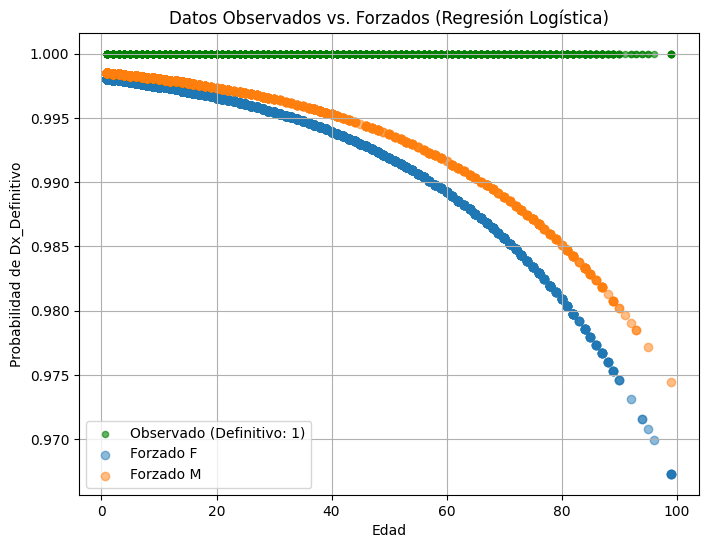

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Obtener las predicciones del modelo para los datos de entrenamiento
df_f = df_interes[df_interes["Sexo"] == "F"]
df_m = df_interes[df_interes["Sexo"] == "M"]

y_pred_f = modelo.predict(df_f)
y_pred_m = modelo.predict(df_m)

# Crear un gráfico de dispersión con los datos observados y forzados
plt.figure(figsize=(8, 6))  # Ajustar el tamaño de la figura si es necesario
#plt.scatter(df_interes["Edad"], df_interes["Dx_Ferropenica"], label="Observado", alpha=0.5)  # Datos observados
plt.scatter(df_interes["Edad"][df_interes["Dx_Definitivo"] == 1],
            df_interes["Dx_Definitivo"][df_interes["Dx_Definitivo"] == 1],
            color='green', label='Observado (Definitivo: 1)', alpha=0.6, s=20)

plt.scatter(df_f["Edad"], y_pred_f, label="Forzado F", alpha=0.5)  # Datos forzados (predichos)
plt.scatter(df_m["Edad"], y_pred_m, label="Forzado M", alpha=0.5)  # Datos forzados (predichos)

plt.xlabel("Edad")
plt.ylabel("Probabilidad de Dx_Definitivo")
plt.title("Datos Observados vs. Forzados (Regresión Logística)")
plt.legend()
plt.grid(True)
plt.show()

# **IV. Referencias**

**Libros y manuales**

- [Libro de estadisitica con python ](https://www.editorial-sciela.org/index.php/sciela/article/view/16/49), [Introducción a la teoria de probabilidades](https://ciladi.org/wp-content/uploads/Version_final_Introduccion-Probabilidad-Python-vf_Bayas-3.pdf), [Guía practica de análsis exploratorio de python](https://datos.gob.es/sites/default/files/doc/file/guia_eda_python.pdf)

**Cursos en linea**

- [Estadística W3School](https://www.w3schools.com/statistics/index.php), [Estadística con python](https://docs.python.org/es/3/library/statistics.html), [Kaggle](https://www.kaggle.com/code/saurav9786/statistics-for-data-scientists)

**Aplicaciones IA**

- [Gemini iA](https://gemini.google.com), [DeepSeek](https://www.deepseek.com/), [ChatGPT](https://chatgpt.com/), [Claude IA](https://claude.ai/), [Julius IA:](https://julius.ai)

